### London Bicycles

#### Fetch data from BigQuery using SQLAlchemy and load it into a pandas DataFrame for EDA.

In [ ]:
# install seaborn in 'elt', polars not installed
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
#import os
# Optional: Set the environment variable for authentication if not already set
# os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/path/to/your/keyfile.json"

# Define your project, dataset, and table names
project_id = 'dsai-001'
credentials_path = ''

# Create the engine, specifying project and/or credentials path
engine = create_engine(f'bigquery://{project_id}', credentials_path=credentials_path)

##### Fetch aggregated data for rental

In [2]:
# Define data source query
dataset_id = "london_bicycles"
table_id = "fact_hire_summary"

query = f"""
SELECT *
FROM `{project_id}.{dataset_id}.{table_id}`
"""

In [3]:
# Use pandas to read SQL query results into DataFrame
df_rental = pd.read_sql(query, con=engine)
print(df_rental.info())

/home/jasmine/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/client.py:613: UserWarning: Cannot create BigQuery Storage client, the dependency google-cloud-bigquery-storage is not installed.
  warnings.warn(


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305379 entries, 0 to 305378
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   rental_year           305379 non-null  int64 
 1   rental_month          305379 non-null  int64 
 2   time_of_day_category  305379 non-null  object
 3   season                305379 non-null  object
 4   start_station_id      305379 non-null  int64 
 5   total_rentals         305379 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 14.0+ MB
None


In [5]:
df_rental.head()

,rental_year,rental_month,time_of_day_category,season,start_station_id,total_rentals
0,2023,1,Evening,Winter,1142,221
1,2023,1,Afternoon,Winter,1053,166
2,2023,1,Afternoon,Winter,200190,126
3,2023,1,Evening,Winter,200003,63
4,2023,1,Evening,Winter,200226,109


In [6]:
df_rental.describe(include='all')

,rental_year,rental_month,time_of_day_category,season,start_station_id,total_rentals
count,305379.000000,305379.000000,305379,305379,3.053790e+05,305379.000000
unique,NaN,NaN,4,4,NaN,NaN
top,NaN,NaN,Afternoon,Autumn,NaN,NaN
freq,NaN,NaN,76429,77949,NaN,NaN
mean,2018.620521,6.474348,NaN,NaN,6.477727e+03,272.271322
std,2.328871,3.468782,NaN,NaN,4.079044e+04,327.166349
min,2015.000000,1.000000,NaN,NaN,1.000000e+00,1.000000
25%,2017.000000,3.000000,NaN,NaN,2.140000e+02,69.000000
50%,2019.000000,7.000000,NaN,NaN,4.410000e+02,190.000000
75%,2021.000000,9.000000,NaN,NaN,6.560000e+02,368.000000


##### Fetch data for stations

In [7]:
# Define data source query
dataset_id = "london_bicycles_star"
table_id = "dim_station"

query = f"""
SELECT *
FROM `{project_id}.{dataset_id}.{table_id}`
"""

In [8]:
# Use pandas to read SQL query results into DataFrame
df_station = pd.read_sql(query, con=engine)
df_station.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             800 non-null    int64  
 1   latitude       800 non-null    float64
 2   longitude      800 non-null    float64
 3   name           800 non-null    object 
 4   bikes_count    800 non-null    int64  
 5   docks_count    800 non-null    int64  
 6   nbEmptyDocks   800 non-null    int64  
 7   terminal_name  800 non-null    object 
 8   install_date   712 non-null    object 
 9   start_total    800 non-null    int64  
 10  end_total      800 non-null    int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 68.9+ KB


In [9]:
df_station.head()

,id,latitude,longitude,name,bikes_count,docks_count,nbEmptyDocks,terminal_name,install_date,start_total,end_total
0,313,51.517344,-0.138073,"Wells Street, Fitzrovia",0,38,38,3495,2010-07-23,137194,140120
1,792,51.505461,-0.104541,"Blackfriars Road, Southwark",0,42,41,300214,2016-02-08,94990,96275
2,215,51.519069,-0.088285,"Moorfields, Moorgate",0,54,54,1092,2010-07-19,188383,207020
3,126,51.517821,-0.096497,"Museum of London, Barbican",0,52,51,1043,2010-07-15,132981,133337
4,427,51.513971,-0.092940,"Cheapside, Bank",0,43,42,22180,2011-07-15,260835,275040


In [10]:
df_station.describe(include='all')

,id,latitude,longitude,name,bikes_count,docks_count,nbEmptyDocks,terminal_name,install_date,start_total,end_total
count,800.000000,800.000000,800.000000,800,800.000000,800.000000,800.00000,800,712,800.000000,800.000000
unique,NaN,NaN,NaN,800,NaN,NaN,NaN,800,228,NaN,NaN
top,NaN,NaN,NaN,"Wells Street, Fitzrovia",NaN,NaN,NaN,3495,2010-07-21,NaN,NaN
freq,NaN,NaN,NaN,1,NaN,NaN,NaN,1,35,NaN,NaN
mean,432.536250,51.505977,-0.127511,NaN,12.690000,26.330000,12.68625,NaN,NaN,97653.268750,97099.560000
std,250.092281,0.020348,0.055243,NaN,9.798158,8.782084,10.34222,NaN,NaN,67983.743121,71115.751619
min,1.000000,51.452997,-0.236770,NaN,0.000000,0.000000,0.00000,NaN,NaN,0.000000,0.000000
25%,213.750000,51.493116,-0.172106,NaN,3.000000,20.000000,4.00000,NaN,NaN,59081.250000,55971.750000
50%,442.500000,51.509191,-0.129698,NaN,12.000000,24.000000,12.00000,NaN,NaN,84639.000000,81635.500000
75%,650.250000,51.520970,-0.090691,NaN,20.000000,30.000000,18.25000,NaN,NaN,120065.000000,117729.000000


#### Visualisations

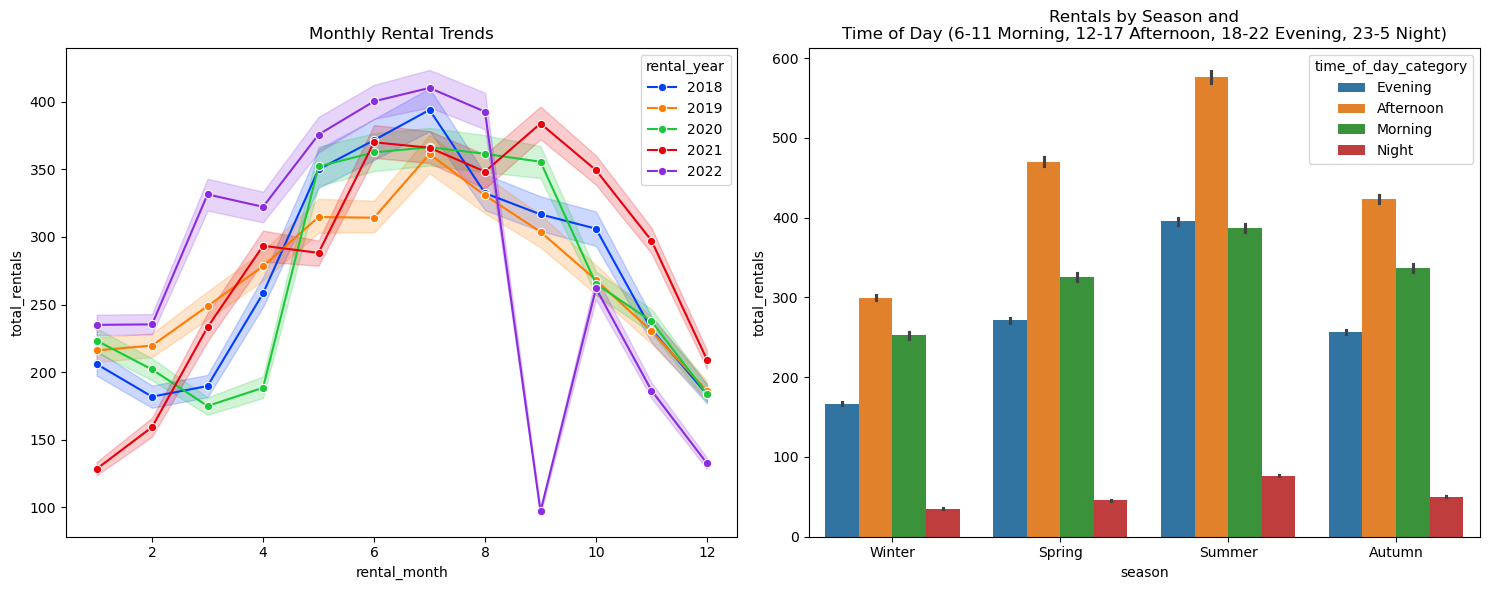

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Monthly rental trends by year
filtered_df = df_rental[(df_rental['rental_year']>=2018) & (df_rental['rental_year'] <= 2022)]
sns.lineplot(data=filtered_df, x='rental_month', y='total_rentals', hue='rental_year', 
             palette='bright', legend='full', marker='o', ax=axes[0])
axes[0].set_title('Monthly Rental Trends')

# Rentals by Season and Time of Day
sns.barplot(data=df_rental, x='season', y='total_rentals', hue='time_of_day_category', ax=axes[1])
axes[1].set_title('Rentals by Season and\nTime of Day (6-11 Morning, 12-17 Afternoon, 18-22 Evening, 23-5 Night)')

plt.tight_layout() # Prevents overlapping labels
plt.show()

**Findings:**  
- Revenue is seasonal and opportunity is concentrated at certain times of a day.
- 2022 September: National mourning following the death of Queen Elizabeth II.
- 2022 October: Dockless competitors expanded services, providing flexible & non-station based usage --> potentially lowered docked bicycles usage.

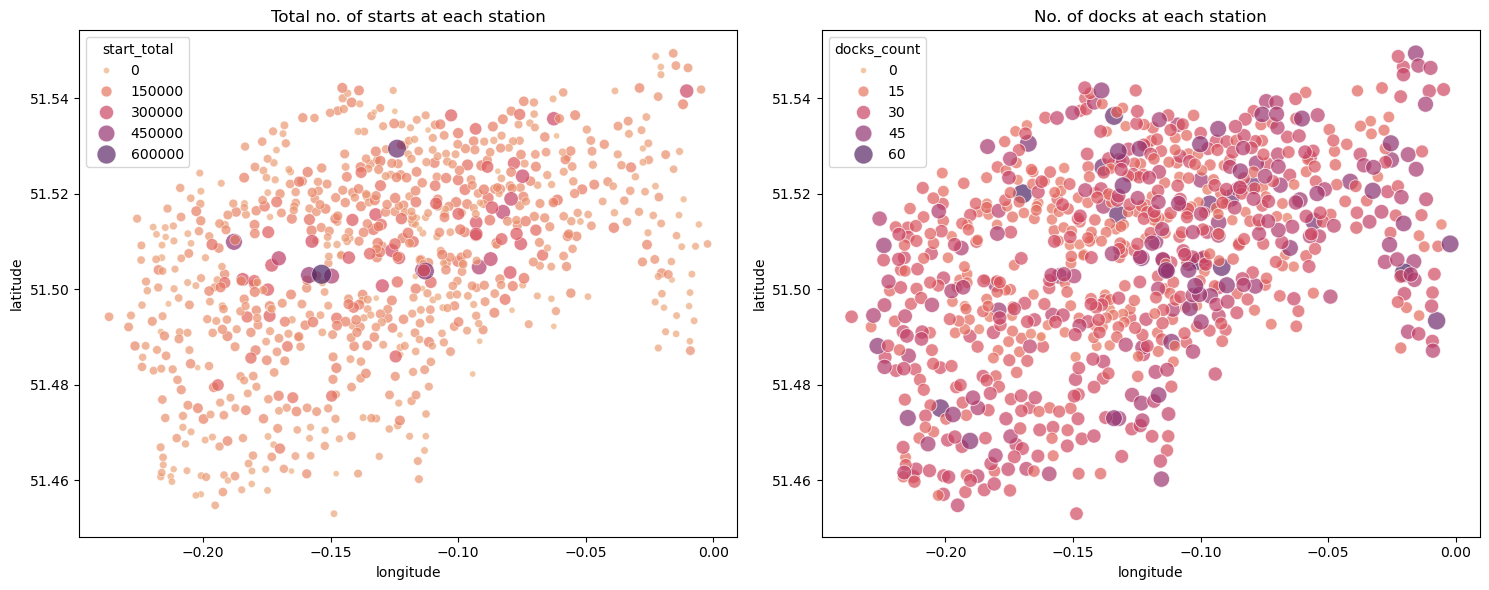

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Total no. of starts at each station
sns.scatterplot(
    data=df_station,
    x='longitude',
    y='latitude',
    hue='start_total',  # Color represents total no. of starts
    size='start_total', # Size represents total no. of starts
    sizes=(20, 200),    # Range of point sizes
    palette='flare',  # Color palette (inferno, magma, plasma, viridis also good)
    alpha=0.7,          # Transparency for overlap
    ax=axes[0]
)
axes[0].set_title('Total no. of starts at each station')

# Docks count at each station
sns.scatterplot(
    data=df_station,
    x='longitude',
    y='latitude',
    hue='docks_count',  # Color represents bike count
    size='docks_count', # Size represents bike count
    sizes=(20, 200),    # Range of point sizes
    palette='flare',  # Color palette (inferno, magma, plasma, viridis also good)
    alpha=0.7,          # Transparency for overlap
    ax=axes[1]
)
axes[1].set_title('No. of docks at each station')

plt.tight_layout()
plt.show()

**Findings:**  
- Higher usage volume originated in central area.
- However, the number of docks at each station is not aligned with the usage volume.

Text(0, 0.5, 'Station')

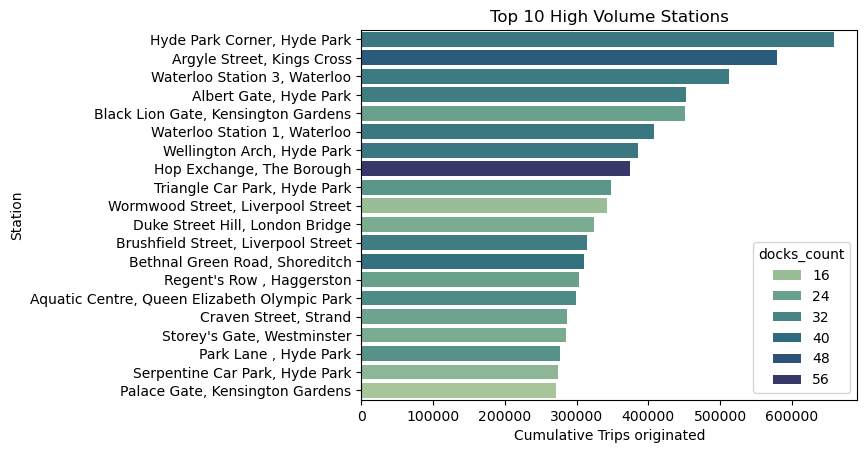

In [52]:
# Stations with high number of trips originated
top20_stations = df_station.sort_values(by='start_total', ascending=False).head(20)
sns.barplot(data=top20_stations, x='start_total', y='name', hue='docks_count', palette='crest')
plt.title('Top 10 High Volume Stations')
plt.xlabel('Cumulative Trips originated')
plt.ylabel('Station')